In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [3]:
# Simple model with one Conv layer (32 filters, 3x3 kernel)
model = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(128, 128, 3))
])

C:\Users\mamoun\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
#Load and process mamoun image
img = tf.keras.preprocessing.image.load_img("mamoun1.jpg", target_size=(128,128))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array / 255.0         # normalize
img_batch = np.expand_dims(img_array, axis=0)


In [ ]:
# Visualize the kernels (weights of each filter)
conv_layer = model.layers[0]

# weights[0] = kernels, weights[1] = biases
kernels, biases = conv_layer.get_weights()

print("Kernel shape:", kernels.shape)    # (3, 3, 3, 32)


Kernel shape: (3, 3, 3, 32)


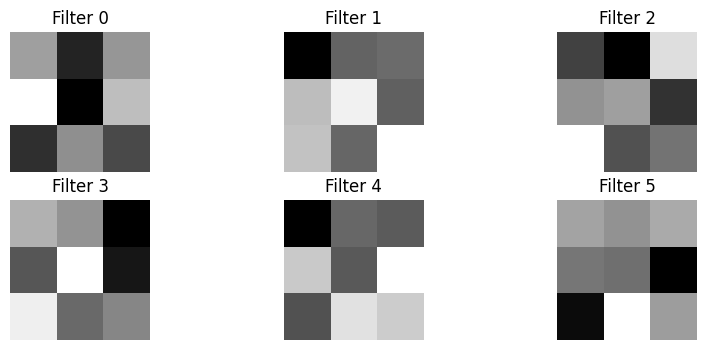

In [ ]:
# Plot the first few kernels (for channel 0)
num_filters_to_show = 6
plt.figure(figsize=(10,4))

for i in range(num_filters_to_show):
    kernel = kernels[:, :, 0, i]   # channel 0 of filter i
    plt.subplot(2, 3, i+1)
    plt.imshow(kernel, cmap='gray')
    plt.title(f"Filter {i}")
    plt.axis('off')

plt.show()
#This shows the actual learned 3×3 kernel patterns


In [ ]:
#Get feature maps (Output of filters)
feature_maps = model.predict(img_batch)
print("Feature maps shape:", feature_maps.shape)  # (1, 126, 126, 32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Feature maps shape: (1, 126, 126, 32)


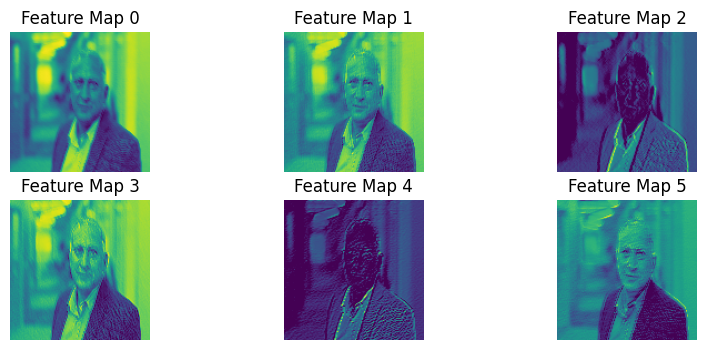

In [ ]:
# Visualize feature maps
num_maps_to_show = 6
plt.figure(figsize=(10,4))

for i in range(num_maps_to_show):
    fmap = feature_maps[0, :, :, i]   # feature map i
    plt.subplot(2, 3, i+1)
    plt.imshow(fmap, cmap='viridis')
    plt.title(f"Feature Map {i}")
    plt.axis('off')

plt.show()
